In [1]:
# Read the optional local data-directory setting.
from os import environ
# Manage local file and directory paths.
from pathlib import Path
# Create temporary directories for this example.
from tempfile import TemporaryDirectory
# Download the published input file.
from urllib.request import urlretrieve

# Arrange and save Matplotlib figures.
import matplotlib.pyplot as plt
# Work with numeric arrays and cell masks.
import numpy as np
# Summarize cells and results in tables.
import pandas as pd

# Open count stores and run Scarf analyses.
import scarf

# Keep routine logs and progress bars out of the results.
scarf.configure_output(level="WARNING", progress=False)

# Use the pinned public H5AD download.
dataset_url = (
    "https://datasets.cellxgene.cziscience.com/"
    "3b751975-34bb-409a-a9b7-98380f0450ea.h5ad"
)
# Choose the local directory for reusable input data.
dataset_directory = Path(environ.get("SCARF_DOCS_DATA_DIR", "scarf_datasets"))
# Create the output directory if needed.
dataset_directory.mkdir(parents=True, exist_ok=True)
# Locate the H5AD file to inspect.
h5ad_path = dataset_directory / "binvignat_ra_pbmc.h5ad"

# Show the local path used by this step.
h5ad_path

PosixPath('/root/docs/source/scarf_datasets/binvignat_ra_pbmc.h5ad')

In [2]:
# Reuse the existing local input when it is already available.
if not h5ad_path.exists():
    # Download to a temporary filename until the file is complete.
    partial_path = h5ad_path.with_suffix(".h5ad.part")
    # Download the published H5AD file.
    urlretrieve(dataset_url, partial_path)
    # Move the completed input into its reusable local path.
    partial_path.replace(h5ad_path)

# Confirm the written filename and its size in bytes.
{"file": h5ad_path.name, "bytes": h5ad_path.stat().st_size}

{'file': 'binvignat_ra_pbmc.h5ad', 'bytes': 259685464}

In [3]:
# Inspect the available count matrices and metadata.
inspection = scarf.inspect_h5ad(str(h5ad_path))
# Require the raw count matrix for pseudobulk.
assert inspection.matrixKey == "raw/X"
# Require integer-like counts for downstream count models.
assert inspection.integerLike is True
# Check the dimensions of the pinned source file.
assert (inspection.nCells, inspection.nFeatures) == (108_717, 21_648)
# Inspect the selected count matrix, encoding, and dimensions.
{
    "matrix": inspection.matrixKey,
    "encoding": inspection.matrixEncoding,
    "integer-like": inspection.integerLike,
    "shape": (inspection.nCells, inspection.nFeatures),
}

{'matrix': 'raw/X',
 'encoding': 'csr',
 'integer-like': True,
 'shape': (108717, 21648)}

In [4]:
# Choose the reusable converted count store.
source_store = dataset_directory / "binvignat_ra_pbmc.zarr"
# Reuse the existing local input when it is already available.
if not source_store.exists():
    # Keep an incomplete conversion separate from the reusable source.
    with TemporaryDirectory(dir=dataset_directory) as conversion_directory:
        # Write the conversion to a temporary store before publishing it locally.
        staged_store = Path(conversion_directory) / source_store.name
        # Open a reader for the selected source format.
        reader = scarf.H5adReader.from_inspect(inspection)
        # Close the input file even if conversion fails.
        try:
            # Write the converted count store.
            scarf.H5adToZarr(
                reader,
                zarr_loc=str(staged_store),
                nthreads=4,
                # The default count layout of these 108,717 cells plans for about 5 GB.
                mem_budget="6G",
            ).dump()
        finally:
            # Close the H5AD input file.
            reader.h5.close()
        # Move the completed input into its reusable local path.
        staged_store.replace(source_store)

# Show the local path used by this step.
source_store

PosixPath('/root/docs/source/scarf_datasets/binvignat_ra_pbmc.zarr')

In [5]:
# Open the converted store with every curated cell retained.
source = scarf.DataStore(
    str(source_store),
    default_assay="RNA",
    min_features_per_cell=0,
    nthreads=4,
)
# Check that importing retained all curated cells.
assert int(np.asarray(source.cells.fetch_all("I"), dtype=bool).sum()) == 108_717

# Inspect the opened store's cells and features.
source

DataStore has 108717 (108717) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'Lane', 
            'MY_CCP_Status', 'MY_MTX', 'MY_RF_status', 'MY_bDMARD', 'MY_cdai', 
            'MY_crp', 'MY_das28crp4', 'MY_das28esr4', 'MY_esr', 'MY_md_global', 
            'MY_pt_global', 'MY_sjc', 'MY_tjc', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'activity_python_binary_crp', 'activity_python_binary_esr', 
            'activity_python_crp', 'activity_python_esr', 'assay', 'assay_ontology_term_id', 'batch', 
            'cell_cycle_diff', 'cell_type', 'cell_type_ontology_term_id', 'dead_cells', 'demux_N_SNP', 
            'demux_PRB_DBL', 'demux_RD_PASS', 'demux_RD_TOTL', 'demux_RD_UNIQ', 'demux_doublet_call', 
            'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 
            'fine_annot', 'is_primary_data', 'leiden_r3.0', 'live_cells', '

In [6]:
# Create a temporary target for this analysis.
analysis_directory = TemporaryDirectory()
# Mount a writable target that keeps counts in the source store.
ds = scarf.mount_datastore(
    str(source_store),
    at=str(Path(analysis_directory.name) / "ra_pseudobulk.zarr"),
    default_assay="RNA",
    min_features_per_cell=0,
    nthreads=4,
)
# Inspect the opened store's cells and features.
ds

DataStore has 108717 (108717) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'Lane', 
            'MY_CCP_Status', 'MY_MTX', 'MY_RF_status', 'MY_bDMARD', 'MY_cdai', 
            'MY_crp', 'MY_das28crp4', 'MY_das28esr4', 'MY_esr', 'MY_md_global', 
            'MY_pt_global', 'MY_sjc', 'MY_tjc', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'activity_python_binary_crp', 'activity_python_binary_esr', 
            'activity_python_crp', 'activity_python_esr', 'assay', 'assay_ontology_term_id', 'batch', 
            'cell_cycle_diff', 'cell_type', 'cell_type_ontology_term_id', 'dead_cells', 'demux_N_SNP', 
            'demux_PRB_DBL', 'demux_RD_PASS', 'demux_RD_TOTL', 'demux_RD_UNIQ', 'demux_doublet_call', 
            'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 
            'fine_annot', 'is_primary_data', 'leiden_r3.0', 'live_cells', '

In [7]:
# Read the donor, condition, batch, pair, and cell-type columns.
cell_metadata = pd.DataFrame(
    {
        column: ds.cells.fetch_all(column)
        for column in (
            "donor_id",
            "disease",
            "batch",
            "pair_index_CW",
            "fine_annot",
        )
    }
)
# Convert matched-pair identifiers to numeric values for selection.
cell_metadata["pair_index_CW"] = pd.to_numeric(
    cell_metadata["pair_index_CW"],
    errors="coerce",
)

# Inspect the first few rows of the result.
cell_metadata.head()

,donor_id,disease,batch,pair_index_CW,fine_annot
0,RA09_1_C_M,rheumatoid arthritis,2,9.0,Classical Monocytes
1,RA09_1_C_M,rheumatoid arthritis,2,9.0,IL1b-Monocytes
2,RA08_1_C_M,rheumatoid arthritis,1,8.0,Myeloid DCs
3,Control03_1_C_F,normal,1,3.0,Myeloid DCs
4,Control10_1_C_F,normal,2,10.0,CD4 T central memory


In [8]:
# Select γδ T cells that have a finite matched-pair identifier.
selection_mask = pd.Series(
    np.isfinite(cell_metadata["pair_index_CW"].to_numpy(dtype=float)),
    index=cell_metadata.index,
) & cell_metadata["fine_annot"].eq("yd T cells")
# Save the calculated values in the cell table.
ds.cells.insert("paired_yd_t_cells", selection_mask.to_numpy(), overwrite=True)
# Freeze the selected cell population before aggregation.
selection = ds.snapshot_cell_selection("paired_yd_t_cells")

# Count the selected cells and represented biological donors.
pd.Series(
    {
        "selected cells": int(selection_mask.sum()),
        "represented donors": int(
            cell_metadata.loc[selection_mask, "donor_id"].nunique()
        ),
    }
)

selected cells        1386
represented donors      36
dtype: int64

In [9]:
# Sum raw counts into one column per biological donor.
bulk = ds.make_bulk(
    "donor_id",
    cell_selection=selection,
    aggr_type="sum",
    feature_label="name",
)
# Check the expected number of expressed genes and donors.
assert bulk.shape == (13_547, 36)
# Inspect a small block of raw donor-level counts.
bulk.iloc[:5, :6]

,Control01_1_A_M,Control03_1_C_F,Control04_1_C_F,Control05_1_C_M,Control06_1_C_M,Control07_1_C_F
LINC01409,0,0,1,0,0,0
LINC00115,0,0,1,0,0,0
SAMD11,1,0,0,0,0,0
NOC2L,0,1,0,0,0,0
KLHL17,0,0,0,0,0,0


In [10]:
# Keep study-design metadata for the selected cells.
selected_metadata = cell_metadata.loc[
    selection_mask,
    ["donor_id", "disease", "batch", "pair_index_CW"],
].copy()

# Count the distinct design values within each donor.
within_donor_levels = selected_metadata.groupby("donor_id", sort=False)[
    ["disease", "pair_index_CW", "batch"]
].nunique(dropna=False)
# Require one condition, pair, and batch value per donor.
assert within_donor_levels.eq(1).all().all()

# Inspect the number of design values found for each donor.
within_donor_levels

,disease,pair_index_CW,batch
donor_id,,,
RA10_1_C_F,1,1,1
Control15_1_C_F,1,1,1
RA09_1_C_M,1,1,1
RA20_1_C_F,1,1,1
Control23_1_C_F,1,1,1
RA06_1_C_M,1,1,1
Control09_1_C_M,1,1,1
RA19_1_A_F,1,1,1
Control16_1_C_F,1,1,1


In [11]:
# Create one design row per donor.
donor_metadata = (
    selected_metadata[["donor_id", "disease", "pair_index_CW", "batch"]]
    .drop_duplicates()
    .set_index("donor_id")
)
# Match donor metadata to the count-matrix column order.
donor_metadata = donor_metadata.reindex(bulk.columns)
# Require one metadata row per donor.
assert donor_metadata.index.is_unique
# Require a complete design for every count column.
assert donor_metadata.notna().all().all()

# Inspect the first few rows of the result.
donor_metadata.head()

,disease,pair_index_CW,batch
Control01_1_A_M,normal,1.0,1
Control03_1_C_F,normal,3.0,1
Control04_1_C_F,normal,4.0,1
Control05_1_C_M,normal,5.0,1
Control06_1_C_M,normal,6.0,1


In [12]:
# Count donors in each condition.
disease_counts = donor_metadata["disease"].value_counts()
# Check that both conditions contain 18 donors.
assert disease_counts.to_dict() == {
    "normal": 18,
    "rheumatoid arthritis": 18,
}

# Count donors within each matched pair.
pair_sizes = donor_metadata.groupby("pair_index_CW").size()
# Count the conditions represented by each matched pair.
pair_conditions = donor_metadata.groupby("pair_index_CW")["disease"].nunique()
# Check that all 18 matched pairs are represented.
assert len(pair_sizes) == 18
# Require exactly two donors per pair.
assert pair_sizes.eq(2).all()
# Require both conditions in each pair.
assert pair_conditions.eq(2).all()

# Count donors in each batch and condition.
donor_metadata.groupby(["batch", "disease"]).size().unstack(fill_value=0)

disease,normal,rheumatoid arthritis
batch,,
1,7,7
2,4,3
3,7,8


In [13]:
# Choose a persistent directory for the exported tables.
export_directory = Path("pseudobulk_exports")
# Create the output directory if needed.
export_directory.mkdir(exist_ok=True)
# Name the raw-count table for the selected cell type.
counts_csv = export_directory / "yd_t_cell_raw_counts.csv"
# Name the donor-design table.
metadata_csv = export_directory / "yd_t_cell_donor_design.csv"

# Write the table to its CSV file.
bulk.to_csv(counts_csv)
# Label the donor identifier column in the exported CSV.
donor_metadata.index.name = "donor_id"
# Write the table to its CSV file.
donor_metadata.to_csv(metadata_csv)
# Show both exported filenames.
print(counts_csv, metadata_csv, sep="\n")

pseudobulk_exports/yd_t_cell_raw_counts.csv
pseudobulk_exports/yd_t_cell_donor_design.csv


In [14]:
# Choose the reported genes for descriptive inspection.
panel_genes = ["IFNG", "IFIT2", "TNF", "GZMA", "ISG15", "S100A4"]
# Check that the plotted genes exist in the aggregated counts.
missing_genes = sorted(set(panel_genes).difference(bulk.index))
# Stop if a requested gene is absent.
assert not missing_genes, f"Missing panel genes: {missing_genes}"

# Calculate each donor's total count depth.
library_sizes = bulk.sum(axis=0)
# Require a positive count total before calculating CPM.
assert library_sizes.gt(0).all()
# Convert counts to log2 CPM for plotting only.
log2_cpm = np.log2(bulk.div(library_sizes, axis=1).mul(1_000_000) + 1)
# Join plotting values with the aligned donor design.
panel = log2_cpm.loc[panel_genes].T.join(donor_metadata)

# Place control and RA expression side by side for each pair.
paired_values = panel.pivot(index="pair_index_CW", columns="disease", values="IFNG")
# Keep control before RA in the paired comparison.
paired_values = paired_values[["normal", "rheumatoid arthritis"]]
# Inspect the first few rows of the result.
paired_values.head()

disease,normal,rheumatoid arthritis
pair_index_CW,,
1.0,0.000000,5.277827
3.0,0.000000,0.000000
4.0,7.143941,0.000000
5.0,5.416623,0.000000
6.0,0.000000,5.930709


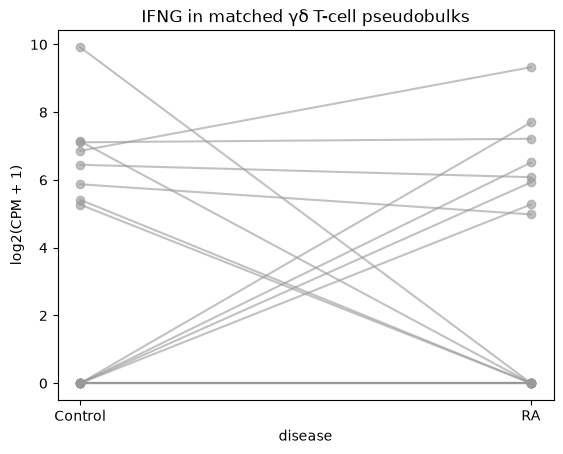

In [15]:
# Draw one line per matched pair.
axis = paired_values.T.plot(marker="o", legend=False, color="0.6", alpha=0.6)
# Label the two conditions in their plotted order.
axis.set_xticks([0, 1], ["Control", "RA"])
# Label the expression scale used for plotting.
axis.set_ylabel("log2(CPM + 1)")
# Label the panel with the result it shows.
axis.set_title("IFNG in matched γδ T-cell pseudobulks")
# Display the completed figure.
plt.show()